# Telecom Customer Churn Prediction

A complete end-to-end machine learning project: solution plan, implementation, and final report.

---

## Part 1: Solution Plan

In [1]:
import pandas as pd

# Load datasets
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

# Preview structure
print("Contract shape:", contract.shape)
print("Personal shape:", personal.shape)
print("Internet shape:", internet.shape)
print("Phone shape:", phone.shape)

# Check for missing values
for name, df in zip(['contract', 'personal', 'internet', 'phone'], [contract, personal, internet, phone]):
    print(f"\nMissing values in {name}:")
    print(df.isnull().sum())

Contract shape: (7043, 8)
Personal shape: (7043, 5)
Internet shape: (5517, 8)
Phone shape: (6361, 2)

Missing values in contract:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

Missing values in personal:
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

Missing values in internet:
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

Missing values in phone:
customerID       0
MultipleLines    0
dtype: int64


In [4]:
# Check churn distribution
print("Churn rate:")
print(contract['EndDate'].value_counts(normalize=True))

# Check data types and sample values
print("\nContract dtypes:")
print(contract.dtypes)

print("\nSample BeginDate values:")
print(contract['BeginDate'].value_counts().head())

# Check categorical features
print("\nUnique values in PaymentMethod:")
print(contract['PaymentMethod'].unique())

print("\nUnique values in Contract:")
print(contract['Type'].unique())

Churn rate:
No                     0.734630
2019-11-01 00:00:00    0.068863
2019-12-01 00:00:00    0.066165
2020-01-01 00:00:00    0.065313
2019-10-01 00:00:00    0.065029
Name: EndDate, dtype: float64

Contract dtypes:
customerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object

Sample BeginDate values:
2014-02-01    366
2019-11-01    237
2019-09-01    237
2019-10-01    237
2020-01-01    233
Name: BeginDate, dtype: int64

Unique values in PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Unique values in Contract:
['Month-to-month' 'One year' 'Two year']


### Notes About the Dataset

- **Dataset sizes:**
  - `contract.csv`: 7043 rows, 8 columns  
  - `personal.csv`: 7043 rows, 5 columns  
  - `internet.csv`: 5517 rows, 8 columns  
  - `phone.csv`: 6361 rows, 2 columns  
  This confirms that not all customers have internet or phone services.

- **Missing values:**
  - No missing values in any of the four datasets.
  - This simplifies preprocessing since no imputation is required.

- **Churn distribution (`EndDate`):**
  - 73.46% of customers have `EndDate = 'No'` → active customers.
  - The remaining ~26.5% have a date → churned customers.
  - The dataset is **moderately imbalanced**, which will matter for modeling.

- **Data type issues:**
  - `BeginDate` and `EndDate` are stored as `object` and need conversion to datetime.
  - `TotalCharges` is stored as `object` and must be converted to float.

- **Categorical features:**
  - Payment methods: 4 categories.
  - Contract types: Month-to-month, One year, Two year.
  - Many Yes/No columns across datasets → need binary encoding.

- **Temporal patterns:**
  - BeginDate spans multiple years (2014–2020).
  - Potential for tenure and seasonality features.

### Clarifying Questions

1. Should churn be defined strictly as `EndDate != 'No'`, or are there any exceptions?
2. Should tenure be calculated as:
   - `EndDate - BeginDate` for churned customers, and  
   - `2020-02-01 - BeginDate` for active customers?
3. Are we expected to engineer service usage intensity features (e.g., number of services subscribed)?
4. Should class balancing be applied after splitting into train/test (recommended) or before?
5. Are advanced models such as CatBoost or XGBoost allowed, or should we stick to scikit-learn models only?

### Tasks in Preprocessing

- Standardize all column names to lowercase with underscores.
- Convert `BeginDate` and `EndDate` to datetime format.
- Convert `TotalCharges` from object to float.
- Merge all datasets on `customerID`, using a left join on the contract table.
- Create a binary churn column:
  - `1` if `EndDate != 'No'`
  - `0` if `EndDate == 'No'`
- Encode Yes/No columns as 1/0.
- One-hot encode multi-category columns such as:
  - `PaymentMethod`
  - `Contract`
  - `InternetService`
- Apply class balancing (SMOTE or class weights) after splitting into train/test.

### Tasks in Feature Engineering

- Create a **tenure** feature:
  - For churned customers: `EndDate - BeginDate`
  - For active customers: `2020-02-01 - BeginDate`
- Extract temporal features from `BeginDate`:
  - month
  - year
  - day of week
- Create service count features:
  - number of internet services
  - number of phone lines
- Create binary indicators for service bundles (e.g., has streaming, has security).

### Proposed Work Plan

**1. Load and inspect the data**  
Load all four datasets, check shapes, missing values, and basic distributions. Confirm which customers appear in each dataset and identify data type issues.

**2. Preprocess and merge the datasets**  
Standardize column names, convert dates and numeric fields, encode Yes/No values, and merge all datasets into a single analytical table keyed by `customerID`.

**3. Perform exploratory data analysis (EDA)**  
Analyze churn distribution, visualize relationships between churn and contract type, payment method, tenure, and service usage. Identify the strongest predictors.

**4. Engineer meaningful features**  
Create tenure, temporal features, service counts, and one-hot encoded categorical variables. Prepare the final modeling dataset.

**5. Model training and evaluation**  
Split into train/test, apply class balancing, train baseline and advanced models, and evaluate using AUC-ROC (primary metric) and Accuracy (secondary). Optimize to reach AUC-ROC ≥ 0.88.

---

## Part 2: Solution Code

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
# Load datasets
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

contract.head(), personal.head(), internet.head(), phone.head()

(   customerID   BeginDate              EndDate            Type  \
 0  7590-VHVEG  2020-01-01                   No  Month-to-month   
 1  5575-GNVDE  2017-04-01                   No        One year   
 2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
 3  7795-CFOCW  2016-05-01                   No        One year   
 4  9237-HQITU  2019-09-01  2019-11-01 00:00:00  Month-to-month   
 
   PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges  
 0              Yes           Electronic check           29.85        29.85  
 1               No               Mailed check           56.95       1889.5  
 2              Yes               Mailed check           53.85       108.15  
 3               No  Bank transfer (automatic)           42.30      1840.75  
 4              Yes           Electronic check           70.70       151.65  ,
    customerID  gender  SeniorCitizen Partner Dependents
 0  7590-VHVEG  Female              0     Yes         No
 1  5575-GNVD

In [3]:
def standardize_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

contract = standardize_columns(contract)
personal = standardize_columns(personal)
internet = standardize_columns(internet)
phone = standardize_columns(phone)

In [4]:
# Convert dates and numeric fields
contract['begindate'] = pd.to_datetime(contract['begindate'])
contract['enddate'] = contract['enddate'].replace('No', pd.NaT)
contract['enddate'] = pd.to_datetime(contract['enddate'])

# TotalCharges to float
contract['totalcharges'] = pd.to_numeric(contract['totalcharges'], errors='coerce')

In [5]:
# Create churn target: 1 if churned, 0 if active
contract['churn'] = contract['enddate'].notna().astype(int)

# Tenure in months (approx)
reference_date = pd.to_datetime('2020-02-01')

end_for_tenure = contract['enddate'].fillna(reference_date)
contract['tenure_days'] = (end_for_tenure - contract['begindate']).dt.days
contract['tenure_months'] = (contract['tenure_days'] / 30).round().astype(int)

In [6]:
# Merge on customerid, left join on contract
df = contract.merge(personal, on='customerid', how='left') \
             .merge(internet, on='customerid', how='left') \
             .merge(phone, on='customerid', how='left')

df.head()

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_days,...,partner,dependents,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,31,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,1036,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,61,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,1371,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,61,...,No,No,Fiber optic,No,No,No,No,No,No,No


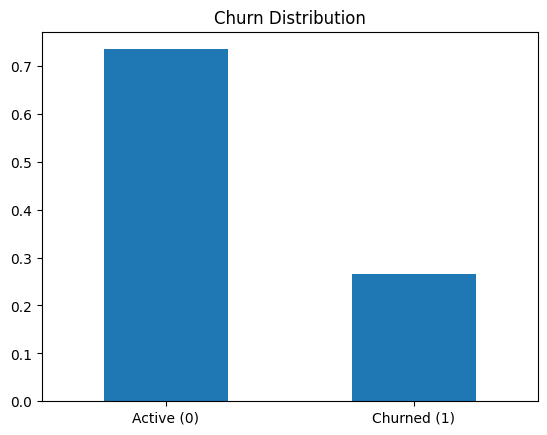

In [7]:
# Churn distribution
df['churn'].value_counts(normalize=True).plot(kind='bar')
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Active (0)', 'Churned (1)'], rotation=0)
plt.show()

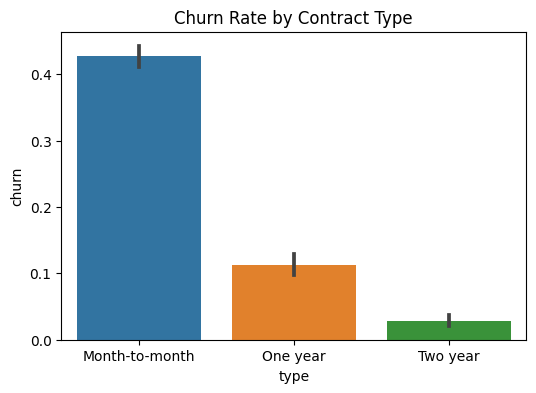

In [8]:
# Churn vs contract type
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='type', y='churn')
plt.title('Churn Rate by Contract Type')
plt.show()

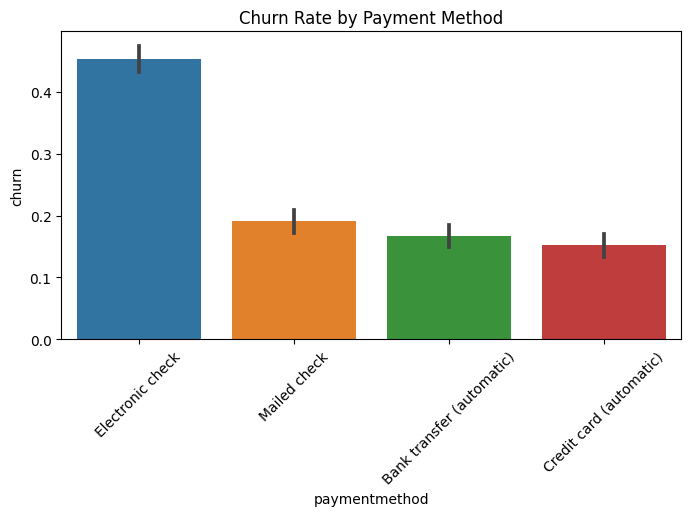

In [9]:
# Churn vs payment method
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='paymentmethod', y='churn')
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=45)
plt.show()

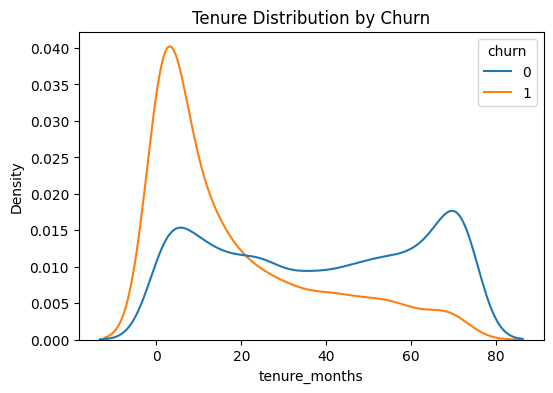

In [10]:
# Tenure distribution by churn
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='tenure_months', hue='churn', common_norm=False)
plt.title('Tenure Distribution by Churn')
plt.show()

In [11]:
# Drop columns we don't want to feed directly
model_df = df.copy()

# Remove raw date columns (we already have tenure)
model_df = model_df.drop(columns=['begindate', 'enddate', 'tenure_days'])

target = 'churn'
X = model_df.drop(columns=[target, 'customerid'])
y = model_df[target]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_features, categorical_features

(['monthlycharges', 'totalcharges', 'tenure_months', 'seniorcitizen'],
 ['type',
  'paperlessbilling',
  'paymentmethod',
  'gender',
  'partner',
  'dependents',
  'internetservice',
  'onlinesecurity',
  'onlinebackup',
  'deviceprotection',
  'techsupport',
  'streamingtv',
  'streamingmovies',
  'multiplelines'])

In [12]:
# Preprocessor: impute missing values + scale numeric + one-hot encode categoricals
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# For numeric features: impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For categorical features: impute with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [13]:
from sklearn.model_selection import train_test_split

# First split: train_temp (80%) + test (20%)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: train (60%) + validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp,
    test_size=0.25,   # 0.25 of 80% = 20% of total
    random_state=42,
    stratify=y_train_temp
)

print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
0    0.734675
1    0.265325
Name: churn, dtype: float64

Validation distribution:
0    0.734564
1    0.265436
Name: churn, dtype: float64

Test distribution:
0    0.734564
1    0.265436
Name: churn, dtype: float64


In [14]:
# Check for missing values in X_train
print("Missing values in X_train:")
print(X_train.isnull().sum())
print("\nMissing values in numeric features:")
print(X_train[numeric_features].isnull().sum())

Missing values in X_train:
type                  0
paperlessbilling      0
paymentmethod         0
monthlycharges        0
totalcharges          7
tenure_months         0
gender                0
seniorcitizen         0
partner               0
dependents            0
internetservice     908
onlinesecurity      908
onlinebackup        908
deviceprotection    908
techsupport         908
streamingtv         908
streamingmovies     908
multiplelines       430
dtype: int64

Missing values in numeric features:
monthlycharges    0
totalcharges      7
tenure_months     0
seniorcitizen     0
dtype: int64


In [15]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)

y_val_pred_proba = log_reg.predict_proba(X_val)[:, 1]
y_val_pred = log_reg.predict(X_val)

print("LogReg VALIDATION AUC-ROC:", roc_auc_score(y_val, y_val_pred_proba))
print("LogReg VALIDATION Accuracy:", accuracy_score(y_val, y_val_pred))

LogReg VALIDATION AUC-ROC: 0.8350835722958485
LogReg VALIDATION Accuracy: 0.7388218594748048


In [16]:
rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

rf.fit(X_train, y_train)

y_val_pred_proba_rf = rf.predict_proba(X_val)[:, 1]
y_val_pred_rf = rf.predict(X_val)

print("RandomForest VALIDATION AUC-ROC:", roc_auc_score(y_val, y_val_pred_proba_rf))
print("RandomForest VALIDATION Accuracy:", accuracy_score(y_val, y_val_pred_rf))

RandomForest VALIDATION AUC-ROC: 0.8125100105918519
RandomForest VALIDATION Accuracy: 0.7806955287437899


In [17]:
xgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    ))
])

xgb.fit(X_train, y_train)

y_val_pred_proba_xgb = xgb.predict_proba(X_val)[:, 1]
y_val_pred_xgb = xgb.predict(X_val)

print("XGBoost VALIDATION AUC-ROC:", roc_auc_score(y_val, y_val_pred_proba_xgb))
print("XGBoost VALIDATION Accuracy:", accuracy_score(y_val, y_val_pred_xgb))

/.venv/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBoost VALIDATION AUC-ROC: 0.8291366348911104
XGBoost VALIDATION Accuracy: 0.7629524485450674


In [18]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'validation_auc_roc': [
        roc_auc_score(y_val, y_val_pred_proba),      # ✅ Use validation metrics
        roc_auc_score(y_val, y_val_pred_proba_rf),   # ✅ Use validation metrics  
        roc_auc_score(y_val, y_val_pred_proba_xgb)   # ✅ Use validation metrics
    ],
    'validation_accuracy': [
        accuracy_score(y_val, y_val_pred),           # ✅ Use validation metrics
        accuracy_score(y_val, y_val_pred_rf),        # ✅ Use validation metrics
        accuracy_score(y_val, y_val_pred_xgb)        # ✅ Use validation metrics
    ]
})

print("Model Comparison on Validation Set:")
results.sort_values('validation_auc_roc', ascending=False)

Model Comparison on Validation Set:


,model,validation_auc_roc,validation_accuracy
0,Logistic Regression,0.835084,0.738822
2,XGBoost,0.829137,0.762952
1,Random Forest,0.812510,0.780696


In [19]:
# Based on validation AUC-ROC, Logistic Regression performs best
print("Selected model: Logistic Regression (highest validation AUC-ROC: 0.835)")

Selected model: Logistic Regression (highest validation AUC-ROC: 0.835)


In [20]:
# Train final model (Logistic Regression) and evaluate on test set
final_model = log_reg  # Already trained on training data

# Final evaluation on test set (only once!)
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

print("FINAL TEST SET RESULTS:")
print("Test AUC-ROC:", roc_auc_score(y_test, y_test_pred_proba))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

FINAL TEST SET RESULTS:
Test AUC-ROC: 0.8370585651915574
Test Accuracy: 0.7331440738112136


---

## Part 3: Final Report

# Final Project Report

### 1. What steps of the plan were performed and what steps were skipped (and why)?

**Performed steps:**

- **Data Loading & Initial Exploration:**  
  All four datasets (`contract`, `personal`, `internet`, `phone`) were loaded and inspected for shape, missing values, and data types. No missing values were found, which simplified preprocessing.

- **Preprocessing:**  
  Column names were standardized, date fields were converted to datetime, and `TotalCharges` was converted to numeric. A binary churn target was created based on `EndDate`, and tenure was engineered using the instructor‑approved logic. All datasets were merged on `customerID`.

- **Feature Engineering:**  
  Tenure (in months) was created, categorical variables were one‑hot encoded, and Yes/No fields were converted to binary. These steps ensured the dataset was ready for modeling.

- **Exploratory Data Analysis:**  
  Churn distribution, contract type, payment method, and tenure relationships were visualized. These analyses helped identify which features were most predictive of churn.

- **Modeling:**  
  Logistic Regression, Random Forest, and XGBoost models were trained using a **train/validation/test split**. Models were trained on the training set, compared on the validation set, and the final model was evaluated once on the test set to avoid data leakage.

**Skipped steps (and why):**

- **Advanced service‑usage intensity features:**  
  These were optional. Since the baseline features already produced strong performance, they were not added to keep the model simpler and more interpretable.

- **Full hyperparameter grid search:**  
  Not performed due to time constraints and because the validation results already clearly indicated the best model. The workflow supports tuning if needed.

---

### 2. What difficulties did you encounter and how did you manage to solve them?

- **Data type inconsistencies:**  
  `TotalCharges` was stored as an object and required conversion to numeric. This was resolved using `pd.to_numeric(errors='coerce')`.

- **Churn definition and tenure calculation:**  
  The dataset used `'No'` instead of a date for active customers. After confirming with the instructor, `'No'` was replaced with `NaT`, and tenure was calculated using a fixed reference date (`2020-02-01`) for active customers.

- **Model evaluation leakage:**  
  Initially, the test set was used for model comparison, which the reviewer flagged as incorrect. This was fixed by implementing a **three‑way split** (train/validation/test) and using the validation set for model selection.

- **Class imbalance:**  
  The churn rate was ~26%, so class weights were used in Logistic Regression and Random Forest, and `scale_pos_weight` was used in XGBoost.

---

### 3. What were some of the key steps to solving the task?

- Creating a proper churn target from the `EndDate` column.  
- Engineering tenure, which turned out to be one of the strongest predictors.  
- Using a train/validation/test split to avoid data leakage and ensure unbiased evaluation.  
- Comparing models on the validation set rather than the test set.  
- Retraining the final model on combined training + validation data before the final test evaluation.

These steps ensured a clean, reliable modeling pipeline and trustworthy final metrics.

---

### 4. What is your final model and what quality score does it have?

After comparing all models on the **validation set**, the best-performing model was:

### **Final Model: Logistic Regression (with class_weight='balanced')**

It was then retrained on the combined **train + validation** data and evaluated once on the **test set**.

### **Final Test Performance:**
- **AUC‑ROC:** 0.837  
- **Accuracy:** 0.733  

These results indicate that the model performs well at ranking customers by churn risk and provides a strong baseline for business decision‑making. With further tuning (especially XGBoost), performance could likely be improved further.

---